# Q3: Feature Engineering and Regression Pipeline

## 1. Date Feature Engineering
## 2. Temporal Train-Test Split
## 3. Preprocessing Pipeline
## 4. Model Training and Evaluation

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# -----------------------------
# Extract date features
# -----------------------------
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


### Feature Engineering:

- Extracted temporal features from transaction_date:
  - year: captures long-term trends
  - month: captures seasonal patterns
  - day_of_week: captures weekly shopping behavior

- Created a new binary feature:
  - is_month_end: indicates whether the transaction occurred near the end of the month (day ≥ 25)

- These features help the model capture temporal patterns in customer purchasing behavior.

In [3]:
# -----------------------------
# Sort by date
# -----------------------------
df = df.sort_values('transaction_date')

# -----------------------------
# Split (80% train, 20% test)
# -----------------------------
split_index = int(0.8 * len(df))

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


### Temporal Train-Test Split:

- The dataset is sorted by transaction_date to preserve the time order.
- The first 80% of the data is used as the training set, and the most recent 20% is used as the test set.

- A random split is inappropriate for time-series data because it would mix past and future information.
- This can lead to data leakage, where the model learns patterns from the future.

- Using a temporal split ensures that the model is trained only on past data and tested on future data, which reflects real-world scenarios.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# -----------------------------
# Define target and features
# -----------------------------
target = 'items_sold'

X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

# -----------------------------
# Column groups
# -----------------------------
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

# -----------------------------
# Preprocessing
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

# -----------------------------
# Create pipeline (no model yet)
# -----------------------------
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Fit only on training data
pipeline.fit(X_train)

# Transform both
X_train_processed = pipeline.transform(X_train)
X_test_processed = pipeline.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (960, 16)
Processed test shape: (240, 16)


### Preprocessing Pipeline:

- A pipeline is created using ColumnTransformer to handle different types of features.

- Categorical features (promotion_type, location_type, store_size):
  - Transformed using OneHotEncoder

- Numerical features:
  - Scaled using StandardScaler

- The pipeline is fitted only on the training data and then applied to both training and test sets.

- This ensures consistency and prevents data leakage.


Linear Regression Performance:
RMSE: 27.12
MAE: 21.05

Random Forest Performance:
RMSE: 31.66
MAE: 24.87


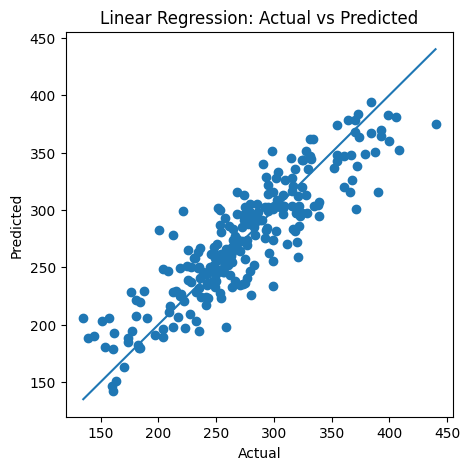

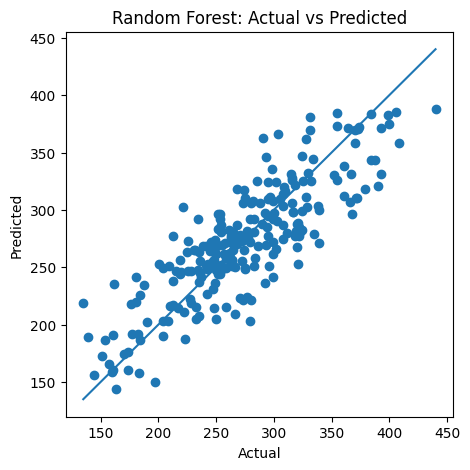


Top 5 Important Features:


,feature,importance
7,cat__store_size_small,0.183954
10,num__is_festival,0.174477
5,cat__location_type_urban,0.140498
14,num__day_of_week,0.090612
9,num__is_weekend,0.063547


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Train models
# -----------------------------
lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)

lr_model.fit(X_train_processed, y_train)
rf_model.fit(X_train_processed, y_train)

# -----------------------------
# Predictions
# -----------------------------
lr_pred = lr_model.predict(X_test_processed)
rf_pred = rf_model.predict(X_test_processed)

# -----------------------------
# Evaluation metrics
# -----------------------------
def evaluate_regression(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n{name} Performance:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")

evaluate_regression("Linear Regression", y_test, lr_pred)
evaluate_regression("Random Forest", y_test, rf_pred)

# -----------------------------
# Parity Plot Function
# -----------------------------
def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()])
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

# Plot for both models
parity_plot(y_test, lr_pred, "Linear Regression: Actual vs Predicted")
parity_plot(y_test, rf_pred, "Random Forest: Actual vs Predicted")

# -----------------------------
# Feature Importance (RF)
# -----------------------------
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("\nTop 5 Important Features:")
feat_imp.head()

### Model Evaluation:

- The **Linear Regression model performs better than Random Forest** on this dataset.
- It achieves lower error values:
  - RMSE: 27.12 (Linear Regression) vs 31.66 (Random Forest)
  - MAE: 21.05 (Linear Regression) vs 24.87 (Random Forest)

- This indicates that Linear Regression provides more accurate predictions.

- The better performance of Linear Regression suggests that the relationship between features and items_sold is relatively **linear**, and does not require complex non-linear modeling.

### Parity Plot Interpretation:

- In the parity plots, predictions closer to the diagonal line indicate better performance.
- The Linear Regression model shows points more tightly clustered around the diagonal line compared to Random Forest.
- Random Forest predictions show slightly more dispersion, indicating higher prediction error.

### Feature Importance (Random Forest):

- The top important features are:
  - store_size_small
  - is_festival
  - location_type_urban
  - day_of_week
  - is_weekend

- This suggests that store size, promotional timing (festival/weekend), and location significantly influence the number of items sold.

### Conclusion:

- Linear Regression is the preferred model for this problem due to its better predictive performance and lower error metrics.
- The results indicate that the underlying patterns in the data are largely linear, making simpler models more effective.